<a href="https://colab.research.google.com/github/pablojbec/Analysis_ConnectaTel/blob/main/Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

El objetivo de este análsis es evaluar el **comportamiento de los clientes** de la empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Se trabajará con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello se trabajará con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso** de los servicios (llamadas y mensajes)  


---
## 🧩 1: Carga y exploración

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa se valida que los archivos se carguen correctamente, y se obtiene información a cerca de sus columnas, tipos y calidad de datos

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, y realizar una revisión preliminar de su contenido.

In [ ]:
# importe de librerías

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

In [ ]:
# cargar archivos
plans = pd.read_csv('D:/Users/Windows 10/Documents/Analisis_datos/Telecom_ConnectaTel/plans.csv')
users = pd.read_csv('D:/Users/Windows 10/Documents/Analisis_datos/Telecom_ConnectaTel/users_latam.csv')
usage = pd.read_csv('D:/Users/Windows 10/Documents/Analisis_datos/Telecom_ConnectaTel/usage.csv')

In [ ]:
# primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
#primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.
  

In [ ]:
#número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar y su manejo para el análisis.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Diagnóstico**:

 - Para users - 'city'(12%) es necesario investigar, imputar NA en estas filas.

 - Para users - 'churn_date'(88%) los datos nulos se deben ignorar puesto que esta información corresponde a fechas de abandono del servicio

 - Para usage - 'date' (0.1%), estos datos nulos corresponden a un caso simple de imputación.

 - Para usage - 'duration'(55%) y 'length'(45%) se ignora ya que estas dos columnas se complementan entre si (MAR)           .


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# columnas numéricas de users
columnasn_users=['user_id','age']
users[columnasn_users].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` muestra valores típicos de asignación de usuario partiendo desde el usuario numero 10000.
- La columna `age` muestra edades hasta los 79 años, sin embargo muestra presencia de sentinels, dado que su valor mínimo es -999, dada la presencia de estos sentinels la columna muestra sesgo hacia la derecha.

In [ ]:
# columnas numéricas de usage
columnasn_usage=['id','user_id','duration','length']
usage[columnasn_usage].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- La columnas `id` y `user_id` muestran valores típicos correspondientes a id de operación de 1 a 40000 y numero de usuario de acuerdo con la tabla users de 10000 a 13999.
- La columna `duration` muestra 17924 valores con min de duración de 0.0 y máximo de duración de llamadas de 120.0, no se evidencia presencia de sentinels, de acuerdo con esto, la columna muestra un sesgo hacia la derecha causado por valores atipicos altos de duración.
- La columna `length` muestra edades longitud de mensajes desde 0 a 1490, no se evidencia presencia de sentinels, de acuerdo con esto, la columna muestra un sesgo hacia la derecha causado por valores atipicos altos de longitud.

In [ ]:
# columnas categóricas de users

columnas_user = ['city', 'plan']
users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [ ]:
# columnas categóricas de users
users['city'].unique()

array(['Medellín', '?', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [ ]:
# columnas categóricas de users
users['plan'].unique()

array(['Basico', 'Premium'], dtype=object)

- La columna `city`muestra 6 ciudades unicas, la moda es Bogotá con frecuencia 808. Presencia de sentinels "?"
- La columna `plan` 2 posibilidades únicas de plan, el plan más adquirido es básico con frecuencia 2595. No se detectan sentinels

In [ ]:
# columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [ ]:
# columna categórica de usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type`  2 posibilidades únicas de uso, la mayoría de clientes usan el servicio para enviar textos, frecuencia 22092.


---
✍️ **Diagnóstico**:
- Se encontraron sentinels numéricos (-999) en la columna age de users y de texto en la columna categórica de city ("?"), para corregir esto de deben estandarizar dichos sentinels.  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [ ]:
# años presentes en `reg_date` de users

print(users['reg_date'].dt.year.unique())
print(users['reg_date'].dt.year.value_counts())

[2022 2026 2023 2024]
reg_date
2024    1330
2023    1316
2022    1314
2026      40
Name: count, dtype: int64


En `reg_date`, se identifican años desde el 2022 hasta el 2024, asi como años imposibles (2026) para ser un dataset con información consignada hasta el año 2024.

In [ ]:
# años presentes en `date` de usage
print(usage['date'].dt.year.unique())
print(usage['date'].dt.year.value_counts())

[2024.   nan]
date
2024.0    39950
Name: count, dtype: int64


En `date`, se identifican que las operaciones se hicieron en el año 2024.

✍️ **Diagnóstico**:
- En reg_date aparece 40 veces el 2026, año imposible, para no afectar la demas información consignada en estas filas, se puede imputar la mediana de la fecha o marcar estas fechas como nulas.
- En date los años son coherentes con la información del dataset.


---

## 🧩3: Limpieza básica de datos

### 3.1 Corrección de sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

In [ ]:
users_clean = users
usage_clean = usage
# Reemplazo de -999 por la mediana de age
age_mediana = users_clean['age'].median()
users_clean['age'] = users_clean['age'].replace(-999, age_mediana)

# Verificación cambios
users_clean['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazo de ? por NA en city
users_clean['city'] = users_clean['city'].replace("?", "NA")
users_clean['city'] = users_clean['city'].fillna("NA")

# Verificación cambios
users_clean['city'].unique()

array(['Medellín', 'NA', 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali'],
      dtype=object)

In [ ]:
# Marcación de fechas futuras como NA para reg_date
users_clean.loc[users_clean['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificación cambios
print("Años después de la corrección:")
print(users_clean['reg_date'].dt.year.value_counts())

Años después de la corrección:
reg_date
2024.0    1330
2023.0    1316
2022.0    1314
Name: count, dtype: int64


### 3.2 Corrección de sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print("Distribución de nulos en duration por type:")
print(
    usage_clean.assign(is_null=usage_clean['duration'].isna())
      .groupby('type')['is_null']
      .value_counts()
      .unstack(fill_value=0)
)

Distribución de nulos en duration por type:
is_null  False  True 
type                 
call     17908      0
text        16  22076


In [ ]:
# Verificación MAR en usage (Miprint("Distribución de nulos en length por type:")
print("Distribución de nulos en length por type:")
print(
    usage_clean.assign(is_null=usage_clean['length'].isna())
      .groupby('type')['is_null']
      .value_counts()
      .unstack(fill_value=0)
)

Distribución de nulos en length por type:
is_null  False  True 
type                 
call        12  17896
text     22092      0


**Diagnóstico**:
Se observa un patrón claro de valores faltantes dependiente de la variable type. La variable duration presenta valores nulos exclusivamente en registros de tipo text, mientras que length presenta nulos exclusivamente en registros de tipo call.

Este comportamiento indica que los datos no son MCAR, ya que la ausencia de información no es aleatoria. En cambio, el patrón es consistente con un mecanismo MAR, donde la disponibilidad de las variables depende de la categoría del registro (type), y no del valor de las variables faltantes en sí.

---

## 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

In [ ]:
# Columnas auxiliares
usage_clean["is_text"] = (usage_clean["type"] == "text").astype(int) #conocer el total de mensajes
usage_clean["is_call"] = (usage_clean["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupación de información por usuario
usage_agg = usage_clean.groupby('user_id').agg({
    'is_text': 'sum',           # Total de mensajes
    'is_call': 'sum',           # Total de llamadas
    'duration': 'sum'           # Total de minutos de llamadas
}).reset_index()

# resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombramiento de columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinación de la tabla agregada con el dataset de usuarios
user_profile = users_clean.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

In [ ]:
# Resumen estadístico de las columnas numéricas
userp_numeric = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[userp_numeric].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize = True)*100

plan
Basico     64.875
Premium    35.125
Name: proportion, dtype: float64

---

## 🧩5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

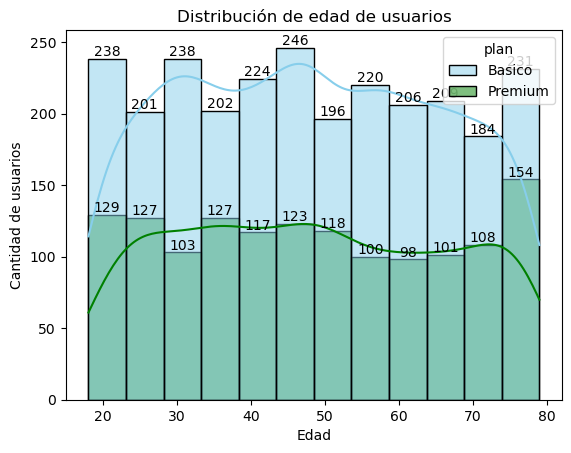

In [ ]:
# Histograma para visualizar la edad (age)
n=int(1+3.3*math.log10(4000))
ax1=sns.histplot(data=user_profile, x='age',hue='plan', bins=n, palette=['skyblue','green'], kde=True)
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.text(p.get_x() + p.get_width()/2,
                height,
                int(height),
                ha="center", va="bottom")
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de edad de usuarios')
plt.show()

💡Insights:
- La columna 'age' muestra una distribución normal con una mayoría de 246 clientes de plan básico entre los 43 y 48 años, y 154 clientes de plan premium entre los 73 y 79 años.

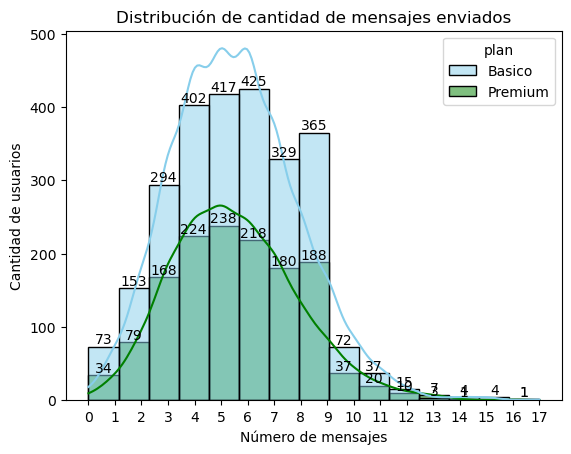

In [ ]:
# Histograma para visualizar la cant_mensajes
ax2=sns.histplot(data=user_profile, x='cant_mensajes',hue='plan', bins=15, palette=['skyblue','green'], kde=True)
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.text(p.get_x() + p.get_width()/2,
                height,
                int(height),
                ha="center", va="bottom")
plt.xlabel('Número de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de cantidad de mensajes enviados')
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17])
plt.show()

💡Insights:
- La distribución de la columna 'cant_mensajes' muestra un sesgo hacia la derecha. Se observa que la mayoría de los clientes que adquirieron el plan básico (425) enviaron 6 mensajes, mientras que, en el caso del plan premium, la mayor parte de los clientes (238) envió 5 mensajes

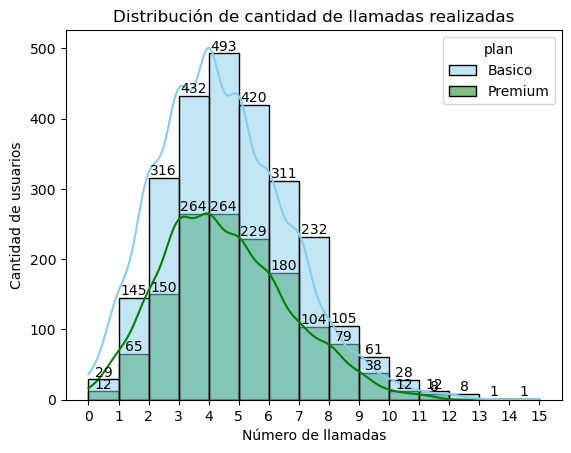

In [ ]:
# Histograma para visualizar la cant_llamadas
ax3=sns.histplot(data=user_profile, x='cant_llamadas',hue='plan', bins=15, palette=['skyblue','green'], kde=True)
for p in ax3.patches:
    height = p.get_height()
    if height > 0:
        ax3.text(p.get_x() + p.get_width()/2,
                height,
                int(height),
                ha="center", va="bottom")
plt.xlabel('Número de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de cantidad de llamadas realizadas')
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])
plt.show()


💡Insights:
- La distribución de 'cant_llamadas' evidencia sesgo hacia la derecha. Se observa que la mayoría de los clientes que adquirieron el plan básico (493) realizaron 4 llamadas, mientra que para el caso del plan premium, la mayor parte de los clientes (264) realizaron 3 y4 llamadas.


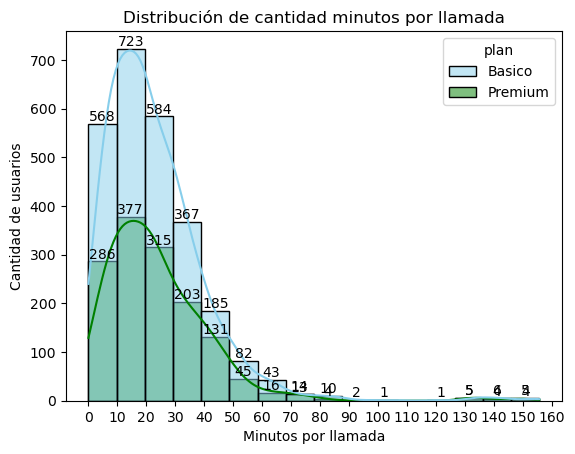

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
ax4=sns.histplot(data=user_profile, x='cant_minutos_llamada',hue='plan', bins=16, palette=['skyblue','green'], kde=True)
for p in ax4.patches:
    height = p.get_height()
    if height > 0:
        ax4.text(p.get_x() + p.get_width()/2,
                height,
                int(height),
                ha="center", va="bottom")
plt.xlabel('Minutos por llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de cantidad minutos por llamada')
plt.xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160])
plt.show()

💡Insights:  
- La distribución de 'cant__minutos_llamadas' evidencia sesgo hacia la derecha. Se observa que la mayoría de los clientes que adquirieron el plan básico (723) y el pan premium (377) tienen una cantidad entre 10 y 20 minutos por llamada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

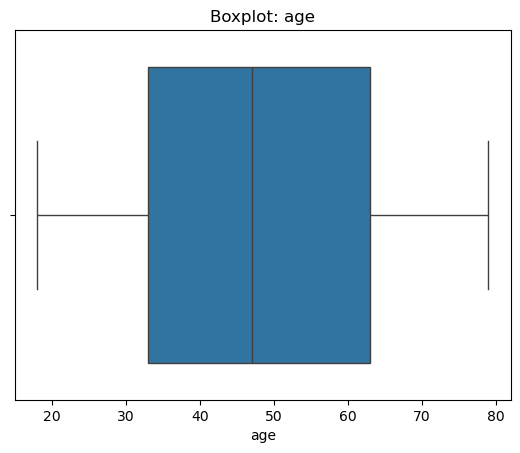

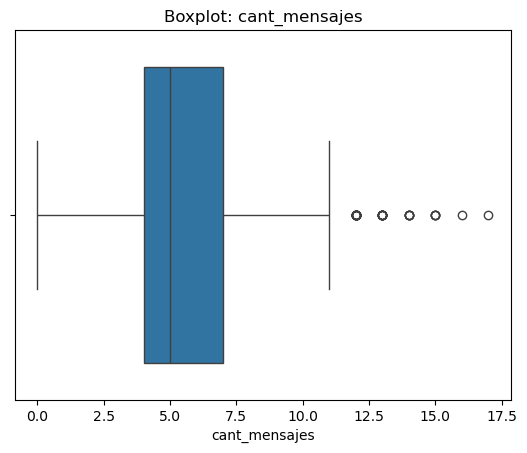

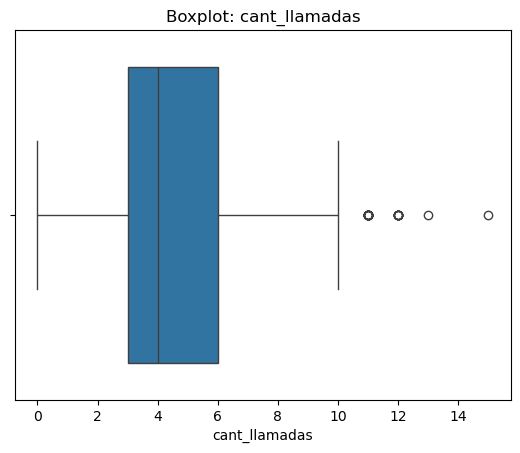

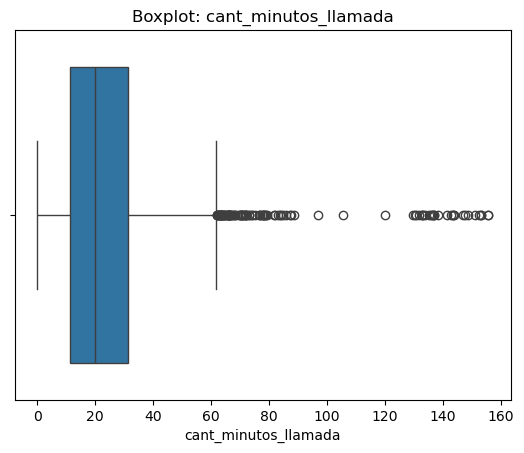

In [ ]:
# BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data = user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: no presenta outliers
- cant_mensajes: presenta outliers
- cant_llamadas: presenta outliers
- cant_minutos_llamada: presenta outliers

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"IQR {col} {IQR}")
    lim_sup = Q3 + 1.5 * IQR
    print(f"Limite superior {lim_sup}")

IQR cant_mensajes 3.0
Limite superior 11.5
IQR cant_llamadas 3.0
Limite superior 10.5
IQR cant_minutos_llamada 20.295
Limite superior 61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener, representa clientes particulares que envían una cantidad alta de mensajes al día.
- cant_llamadas: mantener, representa clientes particulares que realizan un numero de llamadas superior al usual.
- cant_minutos_llamada: mantener, representa clientes particulares que realizan llamadas de alta duración.

---

## 🧩6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

In [ ]:
# Segmentación columna grupo_uso
def classify_use(row):
    msj = row['cant_mensajes']
    llam = row['cant_llamadas']

    # Segmentación de por uso
    if llam < 5 and msj < 5:
        return "Bajo uso"
    elif llam < 10 and msj < 10:
         return "Uso medio"
    else: # resto de casos
        return "Alto uso"


# aplicación de función y visualización de cambios
user_profile['grupo_uso'] = user_profile.apply(classify_use, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

In [ ]:
# Segmentación columna grupo_edad
def classify_age(row):
    age = row['age']

    # Segmentación de por uso
    if age < 30:
        return "Joven"
    elif age < 60:
         return "Adulto"
    else: # resto de casos
        return "Adulto Mayor"


# aplicación de función y visualización de cambios
user_profile['grupo_edad'] = user_profile.apply(classify_age, axis=1)

In [ ]:
# verificación de cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

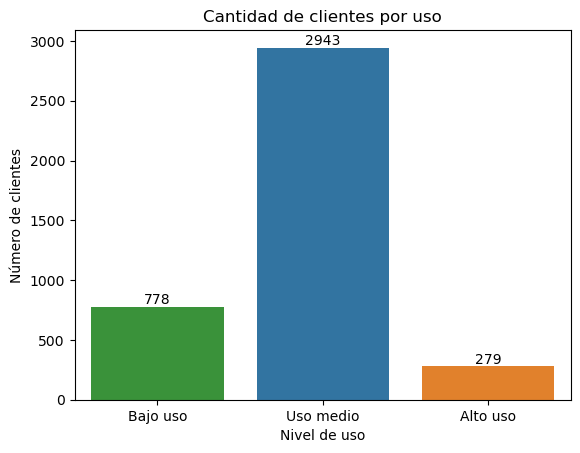

In [ ]:
# Visualización de los segmentos por uso
orden = ["Bajo uso", "Uso medio", "Alto uso"]

ay = sns.countplot(
    x="grupo_uso",
    data=user_profile,
    order=orden,
    hue="grupo_uso",
    palette=["#1f77b4", "#ff7f0e", "#2ca02c"],
    legend=False
)

for p in ay.patches:
    ay.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title("Cantidad de clientes por uso")
plt.xlabel("Nivel de uso")
plt.ylabel("Número de clientes")
plt.show()


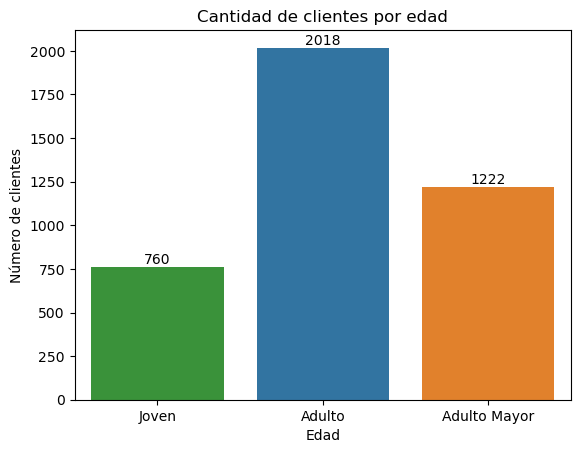

3


In [ ]:
# Visualización de los segmentos por edad
orden = ["Joven", "Adulto", "Adulto Mayor"]
ay1 = sns.countplot(
    x="grupo_edad",
    data = user_profile,
    order = orden,
    hue="grupo_edad",
    palette=["#1f77b4", "#ff7f0e", "#2ca02c"],
    legend=False
)

for p in ay1.patches:
    ay1.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.title("Cantidad de clientes por edad")
plt.xlabel("Edad")
plt.ylabel("Número de clientes")
plt.show()

print(user_profile['grupo_edad'].nunique())


---
## 🧩Paso 7: Análisis Ejecutivo para Stakeholders

**Contexto & Objetivo:**
- Este análisis evalúa el comportamiento del uso de las llamadas y los textos, de los usuarios de la empresa latinoamericana de telecomunicaciones ConnectaTel en fechas anteriores al 2024.
- Los resultados muestran que el público objetivo principal de la empresa son adultos entre los 30 y 60 años de edad, que usan el servicio de manera media, entre 5 y 10 mensajes y llamadas.
- Las variables análizadas permiten dimensionar el impacto del comportamiento de los usuarios del servicio para la toma de decisiones estrategicas que impulsen la expansión en el mercado de la empresa ConnetaTel en latinoamerica.

**Cobertura de datos:**
-El análisis abarca operaciones realizadas por los usuarios en fechas iguales o anteriores al año 2024, las características de los diferentes tipos de plan y los usuarios registrados a los cuales se les presta el servicio de telecomunicaciones.

**Metodología:**
Se realizó la limpieza y validación de los datos, corrigiendo formatos numéricos y de fecha, y verificando la ausencia de valores negativos o inconsistentes en el las variables pincipales ('age', 'duration' y 'length'). Posteriormente, limpiaron las fechas inconsistentes y se creo un nuveo dataset con la información relevante para el análisis ( la información del usuario, la cantidad de minutos, cantidad de llamadas y el tiempo total de llamadas)

Se graficaron las distribuciones de la edad, la cantidad de minutos, cantidad de llamadas y el tiempo total de llamadas para analizar el comportamiento de su distribución y las diferencias de este para cada tipo de plan.

Ssegmentaron los clientes según su edad(Joven < 30, Adulto < 60 y Adulto Mayor > 60) y nivel de uso (Bajo uso  para llamadas y mensajes  < 5, Uso medio cuando llamadas y mensajes < 10, y Alto uso para el resto de casos) para evaluar el comportamiento de los usuarios y proporcionar recomendacioneses.Se, se elaboraron gráfichistogramas, os (bots ypcountplotsas y comparativos) para facilitar el análisis y la visualización de los resultados?

✍Hallazgos inicialestivo:**

- El análisis exploratorio del conjunto de datos identificó varios problemas de calidad. Se detectaron valores centinela (por ejemplo -999 en la columna 'age' y "?" en la columna 'city') utilizados para representar datos faltantes. Asimismo, filas con valores nulos en variables clave como 'city' (12%), 'date' (0.12%),'churn_date' (88%), 'duration'(55%) y 'length' (45%). En las filas de 'duration' y 'length' se observó un patrón consistente con datos faltantes no completamente aleatorios (MAR), lo que sugiere dependencia con otras variables. Adicionalmente, se observaron inconsistencias en los datos, como valores fuera de rango (fechas del año 2026 en la columna 'date').

- Se identificaron segmentos de clientes según su edad(Joven < 30, Adulto < 60 y Adulto Mayor > 60) y nivel de uso (Bajo uso  para llamadas y mensajes  < 5, Uso medio cuando llamadas y mensajes < 10, y Alto uso para el resto de casos). Se identificó que minoria de clientes en los grupos Joven y Alto uso, se observa una base sólida (1222) de Adultos mayores haciendo uso de los servicios.

- Dentro de los segmentos identificados, los que parecen más valiosos para ConnectaTel en primer lugar se encuentran los adultos (2018) con un nivel de uso medio(2943), puesto que hacen parte de la mayoría de los clientes de ConnectaTel y por consiguiente su fuente principal de ingresos. En segundo logar se encuentran los Adultos mayores (1222), que representan una segunda fuente importante de ingresos.

- Respecto a patrones de uso extremo (outliers) identificados, se identifican comportamientos uso alto del servicio en clientes con plan básico, mientras que en los clientes con el plan premium se observa este comportamiento de manera menos frecuente, con un uso más normalizado.

**Recomendaciones**
- Mantener e incentivar con campañas los grupos de Adultos y Uso medio para sobrepasar los 3000 clientes en cada una de estas categorías.
- Promover campañas que incentiven el uso del servicio por parte de grupos Jovenes, de manera que se aumente el número de clientes con esta edad, proponer metas cómo superar los 1000 clientes jóvenes.
- Monitorear el comportamiento de los clientes detro del grupo de bajo uso, puesto que estos 778  clientes pueden representar personas con riesgo de abandono del servicio. idear campañas para minimizar dicho riesgo.
- Identificar posibles campañas para expandir el mercado hacia adultos mayores. Proponer metas como llegar a los 3000 clientes Adultos mayores.

### Puntos Principales análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Sentinels ( -999 en la columna 'age' y "?" en la columna 'city')
- Valores nulos en 'city' (12%), 'date' (0.12%),'churn_date' (88%), 'duration'(55%) y 'length' (45%).
- Filas de 'duration' y 'length' con datos faltantes no completamente aleatorios (MAR), dependencia con otras variables. Adicionalmente, se observaron
- Valores fuera de rango (fechas del año 2026 en la columna 'date').


🔍 **Segmentos por Edad**
- Joven < 30.
- Adulto < 60.
- Adulto Mayor > 60.
- Minoria en segmento Joven (760).
- Base sólida (1222) de Adultos mayores.


📊 **Segmentos por Nivel de Uso**
- Bajo uso  - llamadas < 5 y mensajes  < 5.
- Uso medio - llamadas < 10 y mensajes < 10.
- Alto uso - llamadas > 10 y mensajes > 10.
- Minoria en segmento Alto uso (778).

💡 **Recomendaciones**
- Mantener comportamiento de segmentos de Adultos y Uso medio.
- Promover campañas en grupos Jovenes.
- Monitorear el comportamiento de los clientes detro del grupo de bajo uso.
- Identificar oportunidad de expandir el mercado en Adultos mayores.